In [ ]:
!python -m nltk.downloader stopwords
!python -m nltk.downloader wordnet
!python -m nltk.downloader omw-1.4
!pip install rank_bm25
!pip install -U sentence-transformers
!pip install transformers
!pip install texthero

/usr/lib/python3.7/runpy.py:125: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
  warn(RuntimeWarning(msg))
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/lib/python3.7/runpy.py:125: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
  warn(RuntimeWarning(msg))
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/usr/lib/python3.7/runpy.py:125: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
  warn(RuntimeWarning(msg))
[nltk_data] Downloading package omw-1.4 to /root/nltk_data

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

#Imports
import glob
import functools
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import re
import numpy as np 
import pandas as pd
import nltk
import time

from rank_bm25 import BM25Okapi
from sklearn.metrics.pairwise import cosine_similarity


# Input data files are available in the read-only "../input/" directory

import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Loading & Preprocessing

In [ ]:
import glob
import csv

read_files = glob.glob('/content/drive/MyDrive/AILA_2019_dataset/Object_casedocs/*')

with open("object_casedocs.csv", "w") as outfile:
    w=csv.writer(outfile)
    for f in read_files:
        with open(f, "r") as infile:
            w.writerow([" ".join([line.strip() for line in infile])])

lst_arr = os.listdir("/content/drive/MyDrive/AILA_2019_dataset/Object_casedocs")
df_filename = pd.DataFrame(lst_arr, columns = ['Name'])

In [ ]:
evaluate = pd.read_csv(r'/content/drive/MyDrive/AILA_2019_dataset/relevance_judgments_priorcases.txt', delimiter = " ", header = None)
evaluate.columns = ["Query_Number", "Q0", "Document" ,"Relevance"]
evaluate=evaluate.drop(columns=["Q0"])
evaluate

,Query_Number,Document,Relevance
0,AILA_Q1,C168,0
1,AILA_Q1,C382,0
2,AILA_Q1,C428,0
3,AILA_Q1,C949,0
4,AILA_Q1,C2303,0
...,...,...,...
145695,AILA_Q50,C1367,0
145696,AILA_Q50,C2079,0
145697,AILA_Q50,C2066,0
145698,AILA_Q50,C1951,0


In [ ]:
evaluate = evaluate.loc[evaluate['Relevance'] == 1]
print(evaluate)

       Query_Number Document  Relevance
1192        AILA_Q1      C14          1
2274        AILA_Q1       C9          1
3076        AILA_Q2      C27          1
3676        AILA_Q2      C22          1
6033        AILA_Q3       C1          1
...             ...      ...        ...
140861     AILA_Q49      C38          1
142203     AILA_Q49      C76          1
142450     AILA_Q49      C92          1
143069     AILA_Q50      C27          1
143844     AILA_Q50      C22          1

[195 rows x 3 columns]


### Corpus Loading

In [ ]:
corpus_array_processed = np.load('/content/drive/MyDrive/corpus.npy').tolist()

### Query Loading


In [ ]:
#to apply all the technique to all the records on dataset
def utils_preprocess_text(text, flg_stemm=True, flg_lemm =True, lst_stopwords=None ):
    text = re.sub(r'[^\w\s]', '', str(text).lower().strip())
    
    #tokenization(convert from string to List)
    lst_text = text.split()
    
    #remove stopwords
    if lst_stopwords is not None:
        lst_text = [word for word in lst_text if word not in
                   lst_stopwords]
        
     #stemming
    if flg_stemm == True:
        ps = nltk.stem.porter.PorterStemmer()
        lst_text = [ps.stem(word) for word in lst_text]
        
    #Lemmentization
    if flg_lemm == True:
        lem = nltk.stem.wordnet.WordNetLemmatizer()
        lst_text = [lem.lemmatize(word) for word in lst_text]
        
    # back to string from list
    text = " ".join(lst_text)
    return text



In [ ]:
test = pd.read_csv("/content/drive/MyDrive/AILA_2019_dataset/Query_doc.txt",delimiter = "|",header=None)
test.columns = ["AILA","NAN", "Query"]
test=test.drop(columns=["AILA","NAN"])

In [ ]:
test['Query_processed'] = test['Query'].apply(lambda x: utils_preprocess_text(x, flg_stemm = False, flg_lemm=True))
test

,Query,Query_processed
0,"The appellant on February 9, 1961 was appointe...",the appellant on february 9 1961 wa appointed ...
1,The appellant before us was examined as prime ...,the appellant before u wa examined a prime wit...
2,This appeal arises from the judgment of the le...,this appeal arises from the judgment of the le...
3,The Petitioner was married to the Respondent N...,the petitioner wa married to the respondent no...
4,This appeal is preferred against the judgment ...,this appeal is preferred against the judgment ...
5,"On 19.3.1999, SI P1 along Ct. P2 went to Villa...",on 1931999 si p1 along ct p2 went to village v...
6,This criminal appeal is directed against the j...,this criminal appeal is directed against the j...
7,"This appeal, by special leave, has been prefer...",this appeal by special leave ha been preferred...
8,The complainant P1 filed a Special Leave Petit...,the complainant p1 filed a special leave petit...
9,"The four appellants, along with P1 son of P2, ...",the four appellant along with p1 son of p2 wer...


In [ ]:

query_array_processed = [0]*50

query_array=test.iloc[:,1:].values

#test["Query_processed"]
#test.values(columns=[test["Query_processed"]])
#query_array[49][0]

for i in range(50):
    query_array_processed[i] = query_array[i][0]

In [ ]:
df = pd.read_csv('object_casedocs.csv',header=None)
df.columns = ["Text"]
df

,Text
0,Vasant Vithu Jadhav v State Of Maharashtra Sup...
1,Paramjit v State Of Haryana Supreme Court of I...
2,Bivash Chandra Debnath @ Bivash D. and others ...
3,Anuj Kumar Gupta @ Sethi Gupta v State of Biha...
4,Northern Indian Glass Industries v Jaswant Sin...
...,...
2909,State of Punjab v Sanjiv Kumar @ Sanju and Oth...
2910,Kunj Beharilal Agarwal v Union of India Suprem...
2911,M.G. Metal Industries v Government of India Su...
2912,Smt. Sitabati Debi and Another v State of West...


In [ ]:
df = pd.concat([df_filename,df], axis = 1)
df

,Name,Text
0,C2074.txt,Vasant Vithu Jadhav v State Of Maharashtra Sup...
1,C2057.txt,Paramjit v State Of Haryana Supreme Court of I...
2,C1854.txt,Bivash Chandra Debnath @ Bivash D. and others ...
3,C1654.txt,Anuj Kumar Gupta @ Sethi Gupta v State of Biha...
4,C1527.txt,Northern Indian Glass Industries v Jaswant Sin...
...,...,...
2910,C2409.txt,Kunj Beharilal Agarwal v Union of India Suprem...
2911,C2091.txt,M.G. Metal Industries v Government of India Su...
2912,C519.txt,Smt. Sitabati Debi and Another v State of West...
2913,C513.txt,National Insurance Company Limited v General I...


In [ ]:

df['clean_text'] = df['Text'].apply(lambda x: utils_preprocess_text(x, flg_stemm = False, flg_lemm=True))

In [ ]:
df

,Name,Text,clean_text
0,C2074.txt,Vasant Vithu Jadhav v State Of Maharashtra Sup...,vasant vithu jadhav v state of maharashtra sup...
1,C2057.txt,Paramjit v State Of Haryana Supreme Court of I...,paramjit v state of haryana supreme court of i...
2,C1854.txt,Bivash Chandra Debnath @ Bivash D. and others ...,bivash chandra debnath bivash d and others v s...
3,C1654.txt,Anuj Kumar Gupta @ Sethi Gupta v State of Biha...,anuj kumar gupta sethi gupta v state of bihar ...
4,C1527.txt,Northern Indian Glass Industries v Jaswant Sin...,northern indian glass industry v jaswant singh...
...,...,...,...
2910,C2409.txt,Kunj Beharilal Agarwal v Union of India Suprem...,kunj beharilal agarwal v union of india suprem...
2911,C2091.txt,M.G. Metal Industries v Government of India Su...,mg metal industry v government of india suprem...
2912,C519.txt,Smt. Sitabati Debi and Another v State of West...,smt sitabati debi and another v state of west ...
2913,C513.txt,National Insurance Company Limited v General I...,national insurance company limited v general i...


## BM250 Ranking

In [ ]:
train_array=df.iloc[:,1:].values
tokenized_corpus = [doc.split(" ") for doc in corpus_array_processed]

NameError: ignored

In [ ]:
from rank_bm25 import BM25Okapi

In [ ]:
name = df["Name"]
name = name.str.rstrip('.txt')
name

0       C2074
1       C2057
2       C1854
3       C1654
4       C1527
        ...  
2910    C2409
2911    C2091
2912     C519
2913     C513
2914    C1748
Name: Name, Length: 2915, dtype: object

In [ ]:
from rank_bm25 import BM25Okapi

query_array_processed = [0]*50

corpus_array_processed = [0]*2914

train_array=df.iloc[:,1:].values

for i in range(2914):
    corpus_array_processed[i] = train_array[i][0]

query_array=test.iloc[:,1:].values

#test["Query_processed"]
#test.values(columns=[test["Query_processed"]])
#query_array[49][0]

for i in range(50):
    query_array_processed[i] = query_array[i][0]

In [ ]:
bm25 = BM25Okapi(tokenized_corpus)
bm25

In [ ]:
name = df["Name"]
name = name.str.rstrip('.txt')

In [ ]:
bm25.get_top_n(query_array_processed[5].split(" "), name, n=10)

AssertionError: ignored

In [ ]:
evaluate = evaluate.loc[evaluate['Relevance'] == 1]
print(evaluate)
print(len(evaluate))

       Query_Number Document  Relevance
1192        AILA_Q1      C14          1
2274        AILA_Q1       C9          1
3076        AILA_Q2      C27          1
3676        AILA_Q2      C22          1
6033        AILA_Q3       C1          1
...             ...      ...        ...
140861     AILA_Q49      C38          1
142203     AILA_Q49      C76          1
142450     AILA_Q49      C92          1
143069     AILA_Q50      C27          1
143844     AILA_Q50      C22          1

[195 rows x 3 columns]
195


In [ ]:
retrieved = bm25.get_top_n(query_array_processed[i].split(" "), name, n=10)
relevant = evaluate.loc[evaluate['Query_Number'] == "AILA_Q"+str(i+1)]["Document"]

In [ ]:
print(retrieved)
print(relevant)

['C823', 'C2316', 'C2311', 'C2462', 'C1623', 'C2242', 'C2313', 'C2846', 'C2699', 'C1688']
143069    C27
143844    C22
Name: Document, dtype: object


In [ ]:
count = 0
for i in range(50):
    for j in bm25.get_top_n(query_array_processed[i].split(" "), name, n=10):
        for k in evaluate.loc[evaluate['Query_Number'] == "AILA_Q"+str(i+1)]["Document"]:
            if (j==k):
                count=count+1

print(count)

AssertionError: ignored

In [ ]:
Precision = count/500
Recall = count/195

print(Precision)
print(Recall)

0.05
0.1282051282051282


## Doc2Vec

In [ ]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import word_tokenize

In [ ]:
tagged_data = [TaggedDocument(words=word_tokenize(_d.lower()), tags=[str(i)]) for i, _d in enumerate(corpus_array_processed)]

In [ ]:
model = Doc2Vec(tagged_data, vector_size=20, window=2, min_count=1, workers=4, epochs = 100)

In [ ]:
model.save("test_doc2vec.model")

In [ ]:
model= Doc2Vec.load("test_doc2vec.model")

In [ ]:
model.docvecs.most_similar([model.infer_vector(word_tokenize(query_array_processed[5]))])

[('2372', 0.8654325008392334),
 ('2315', 0.8588691353797913),
 ('643', 0.8571668267250061),
 ('783', 0.8545117378234863),
 ('635', 0.8524176478385925),
 ('1145', 0.8519745469093323),
 ('777', 0.8457356691360474),
 ('418', 0.8389806747436523),
 ('1101', 0.8389389514923096),
 ('655', 0.8388099074363708)]

In [ ]:
count = 0
for i in range(50):
    for j in model.docvecs.most_similar(positive=[model.infer_vector(word_tokenize(query_array_processed[i]))],topn=10)[0][0]:
        temp = evaluate.loc[evaluate['Query_Number'] == "AILA_Q"+str(i+1)]["Document"]
        for k in temp.str.replace('C', ''):
            if (j==k):
                count=count+1

print(count)

4


In [ ]:
Precision = count/500
Recall = count/195

print(Precision)
print(Recall)

0.008
0.020512820512820513


## TFIDF

In [ ]:
import pandas as pd
import nltk
import string

from os import listdir
from os.path import isfile, join

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
corpus = corpus_array_processed
vectorizer = TfidfVectorizer(max_features=16)
X = vectorizer.fit_transform(corpus)
#vectorizer.get_feature_names_out()
print(X.shape)


(2914, 16)


In [ ]:
tfidf = TfidfVectorizer(max_features=16)
tfs = tfidf.fit_transform(query_array_processed)
#print("--------------tf Values---------------------------------")
tfs_Values = tfs.toarray()
#print(tfs_Values)
#print("--------------tfs Terms     ----------------------------")
tfs_Term = tfidf.get_feature_names()
#print(tfs_Term)



In [ ]:
print(tfs.shape)

(50, 16)


In [ ]:
print(X.shape)

(2914, 16)


In [ ]:
q_name=[]
for i in range(50):
    q_name.append(i)
cosineSimilarity = cosine_similarity(tfs,X)
cosineSimilarityDf = pd.DataFrame(cosineSimilarity,index=(q_name),columns=(df_filename))
sortedDateFrame=cosineSimilarityDf.sort_index().sort_index(axis=1, ascending=True)
print(sortedDateFrame)

    (C1.txt,)  (C10.txt,)  (C100.txt,)  (C1000.txt,)  (C1001.txt,)  \
0    0.549982    0.393241     0.356267      0.394658      0.394965   
1    0.526724    0.375389     0.339140      0.376656      0.371840   
2    0.544457    0.381761     0.375226      0.413070      0.383884   
3    0.592165    0.461563     0.428103      0.462165      0.433751   
4    0.627523    0.526504     0.477073      0.504211      0.497710   
5    0.683446    0.580426     0.549657      0.591116      0.570260   
6    0.633566    0.505454     0.485285      0.517418      0.497314   
7    0.625330    0.505196     0.473469      0.514697      0.516293   
8    0.530214    0.374426     0.326757      0.360349      0.357698   
9    0.667011    0.566202     0.548238      0.576849      0.564252   
10   0.628125    0.489254     0.461282      0.501526      0.483598   
11   0.607084    0.518004     0.453392      0.491534      0.501143   
12   0.597979    0.439872     0.413720      0.464058      0.470009   
13   0.663878    0.5

In [ ]:
sortedDateFrame.iloc[0].nlargest(10).index

Index([('C1335.txt',), ('C2027.txt',), ('C1696.txt',),    ('C1.txt',),
        ('C940.txt',),  ('C185.txt',),   ('C89.txt',), ('C2399.txt',),
       ('C1131.txt',),  ('C323.txt',)],
      dtype='object')

In [ ]:
count = 0
for i in range(50):
    z=[]
    for q in list(sortedDateFrame.iloc[i].nlargest(20).index):
        z.append(q[0].split('.')[0])
    for j in z:
        for k in evaluate.loc[evaluate['Query_Number'] == "AILA_Q"+str(i+1)]["Document"]:
            if (j==k):
                count=count+1   
    print(z,count)            
print(count)

['C1335', 'C2027', 'C1696', 'C1', 'C940', 'C185', 'C89', 'C2399', 'C1131', 'C323', 'C513', 'C94', 'C1386', 'C1472', 'C1706', 'C2771', 'C2028', 'C5', 'C2229', 'C541'] 0
['C1335', 'C1696', 'C2027', 'C1131', 'C89', 'C1', 'C940', 'C185', 'C2399', 'C1386', 'C1706', 'C1472', 'C623', 'C513', 'C323', 'C94', 'C2229', 'C5', 'C2771', 'C451'] 0
['C1335', 'C1696', 'C2027', 'C1', 'C2399', 'C1131', 'C185', 'C323', 'C1706', 'C513', 'C89', 'C940', 'C1472', 'C5', 'C1386', 'C623', 'C926', 'C541', 'C451', 'C2771'] 1
['C1335', 'C2027', 'C1696', 'C1131', 'C94', 'C1386', 'C185', 'C940', 'C1', 'C1472', 'C2399', 'C31', 'C89', 'C2772', 'C623', 'C2771', 'C323', 'C1706', 'C513', 'C451'] 1
['C1335', 'C2027', 'C1696', 'C1131', 'C284', 'C2399', 'C1472', 'C926', 'C1851', 'C1386', 'C940', 'C185', 'C89', 'C623', 'C1777', 'C2701', 'C2694', 'C2771', 'C1406', 'C1503'] 1
['C1335', 'C2027', 'C1696', 'C2399', 'C185', 'C940', 'C1131', 'C1386', 'C1472', 'C94', 'C2771', 'C926', 'C451', 'C623', 'C89', 'C284', 'C2053', 'C166', 'C

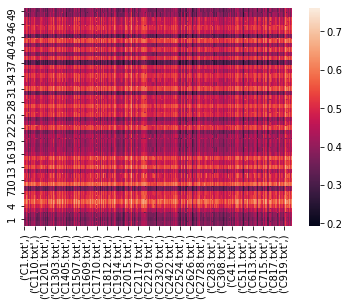

In [ ]:
import seaborn as sns
p1 = sns.heatmap(cosineSimilarityDf.sort_index(axis=0, ascending=False).sort_index(axis=1, ascending=True))

## **LegalBERT Base**

In [ ]:
from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-base-uncased")
model = AutoModel.from_pretrained("nlpaueb/legal-bert-base-uncased")

Downloading:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/0.99k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/217k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/420M [00:00<?, ?B/s]

Some weights of the model checkpoint at nlpaueb/legal-bert-base-uncased were not used when initializing BertModel: ['cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.decoder.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
from transformers import AutoModel, AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("readerbench/jurBERT-large")
model = AutoModel.from_pretrained("readerbench/jurBERT-large")

Some weights of the model checkpoint at readerbench/jurBERT-large were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
sen = corpus_array_processed
z = []
start = time.time()
limit = 100
for i in range(len(sen)):

  encoded_input = tokenizer(sen[i],return_tensors="pt",max_length=512,truncation=True)
  outputs = model(**encoded_input)
  outputs_np = np.array(outputs[1].detach().numpy())
  print(outputs_np.shape)
  z.append(outputs_np[0])
  if i % 10 == 0:
    print("Completed: ", i , "/" , limit)
  if i == limit:
    break
end = time.time()
print((end - start))

np.save('/content/drive/MyDrive/corpus_base_bert_embeddings.npy',np.array(z))

(1, 1024)
Completed:  0 / 100
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
Completed:  10 / 100
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
Completed:  20 / 100
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
Completed:  30 / 100
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
Completed:  40 / 100
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
Completed:  50 / 100
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
Completed:  60 / 100
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
Completed:  70 / 100
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
(1, 1024)
Completed:  80 / 100
(1

In [ ]:
query_sen = query_array_processed
qz = []
start = time.time()
for i in range(len(query_sen)):

  encoded_input = tokenizer(query_sen[i], return_tensors='pt',max_length=512,padding=True,truncation=True)
  outputs = model(**encoded_input)
  outputs_np = np.array(outputs[1].detach().numpy())
  qz.append(outputs_np[0])
  if i % 10 == 0:
    print("Completed: ", i )
end = time.time()
print((end - start))

np.save('/content/drive/MyDrive/query_base_bert_embeddings.npy',np.array(qz))

Completed:  0
Completed:  10
Completed:  20
Completed:  30
Completed:  40
282.9202711582184


In [ ]:
corpus_embeddings = np.load('/content/drive/MyDrive/corpus_base_bert_embeddings.npy').tolist()
query_embeddings = np.load('/content/drive/MyDrive/query_base_bert_embeddings.npy').tolist()

In [ ]:
print(np.array(corpus_embeddings).shape)
print(np.array(query_embeddings).shape)

(101, 1024)
(50, 1024)


In [ ]:
count = 0
for i in range(50):
    sl = cosine_similarity([query_embeddings[i]],corpus_embeddings)
    sl2 = np.argsort(sl[0])[::-1]
    pred = []
    for q in range(20):
        pred.append(df_filename.iloc[sl2[q]]['Name'].split('.')[0])
    for j in pred:
        for k in evaluate.loc[evaluate['Query_Number'] == "AILA_Q"+str(i+1)]["Document"]:
          if (j==k):
              count=count+1
    # print(pred,count)            

print(count)

1


In [ ]:
Precision = count/500
Recall = count/195

print(Precision)
print(Recall)

0.002
0.005128205128205128


In [ ]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 4.4 MB 5.1 MB/s 
     |████████████████████████████████| 6.6 MB 52.5 MB/s 
     |████████████████████████████████| 101 kB 12.8 MB/s 
     |████████████████████████████████| 596 kB 73.3 MB/s 
  Attempting uninstall: pyyaml
    Found existing installation: PyYAML 3.13
    Uninstalling PyYAML-3.13:
      Successfully uninstalled PyYAML-3.13


## **LegalBERT Small**


In [ ]:
from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("nlpaueb/legal-bert-small-uncased")
model = AutoModel.from_pretrained("nlpaueb/legal-bert-small-uncased")

Downloading:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/989 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/217k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of the model checkpoint at nlpaueb/legal-bert-small-uncased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.predictions.decoder.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
sen = corpus_array_processed
z = []
start = time.time()
for i in range(len(sen)):

  encoded_input = tokenizer(sen[i], return_tensors='pt',padding=True,truncation=True)
  outputs = model(**encoded_input)
  outputs_np = np.array(outputs[1].detach().numpy())
  z.append(outputs_np[0])
  if i % 100 == 0:
    print("Completed: ", i )
  # if i == limit:
  #   break
end = time.time()
print((end - start))

np.save('/content/drive/MyDrive/corpus_small_bert_embeddings.npy',np.array(z))

NameError: ignored

In [ ]:
query_sen = query_array_processed
qz = []
start = time.time()
for i in range(len(query_sen)):

  encoded_input = tokenizer(query_sen[i], return_tensors='pt',padding=True,truncation=True)
  outputs = model(**encoded_input)
  outputs_np = np.array(outputs[1].detach().numpy())
  qz.append(outputs_np[0])
  if i % 10 == 0:
    print("Completed: ", i )
end = time.time()
print((end - start))

np.save('/content/drive/MyDrive/query_small_bert_embeddings.npy',np.array(qz))

Completed:  0
Completed:  10
Completed:  20
Completed:  30
Completed:  40
17.69892716407776


In [ ]:
corpus_embeddings = np.load('/content/drive/MyDrive/corpus_small_bert_embeddings.npy').tolist()
query_embeddings = np.load('/content/drive/MyDrive/query_small_bert_embeddings.npy').tolist()

In [ ]:
print(np.array(corpus_embeddings).shape)
print(np.array(query_embeddings).shape)

(2914, 512)
(50, 512)


In [ ]:
def get_line_count(case_file_no):
  case_file = '/content/drive/MyDrive/0_0_0_0_sih/AILA_2019_dataset/Object_casedocs/' + str(case_file_no) + '.txt'
  with open(case_file,'r') as f:
    line_cnt = 0
    for line in f.readlines():
      line_cnt += 1
    return line_cnt

30

In [ ]:
count = 0
for i in range(50):
    sl = cosine_similarity([query_embeddings[i]],corpus_embeddings)
    sl2 = np.argsort(sl[0])[::-1]
    pred = []
    for q in range(10):
        pred.append(df_filename.iloc[sl2[q]]['Name'].split('.')[0])
    for j in pred:
        for k in evaluate.loc[evaluate['Query_Number'] == "AILA_Q"+str(i+1)]["Document"]:
          if (j==k):
              line_count = get_line_count(k)
              # print(i,j,k, line_count)
              count=count+1
    # print(pred,count)            

print(count)

NameError: ignored

In [ ]:
Precision = count/500
Recall = count/195

print(Precision)
print(Recall)

0.004
0.010256410256410256
